# Ajuste de curvas

<img style="float: right; margin: 0px 0px 15px 15px;" src="https://upload.wikimedia.org/wikipedia/commons/a/a8/Regression_pic_assymetrique.gif" width="400px" height="300px" />

> El **ajuste de curvas** es el proceso de construir una curva (función), que sea el mejor ajuste a una serie de puntos. Las curvas ajustadas pueden ser usadas como asistencia en la visualización de datos, para inferir valores de una función donde no hay datos disponibles, y para resumir la relación entre variables.

**Referencia**:
- https://en.wikipedia.org/wiki/Curve_fitting
___

## Problema básico

<img style="float: right; margin: 0px 0px 15px 15px;" src="https://upload.wikimedia.org/wikipedia/commons/3/3a/Linear_regression.svg" width="400px" height="200px" />

Consideramos que tenemos un conjunto de n pares ordenados de datos $(x_i,y_i)$, para $i=1,2,3,\dots,n$.

### ¿Cuál es la recta que mejor se ajusta a estos datos?
Consideramos entonces ajustes de la forma $\hat{f}(x) = \beta_0+\beta_1 x = \left[1 \quad x\right]\left[\begin{array}{c} \beta_0 \\ \beta_1 \end{array}\right]=\left[1 \quad x\right]\boldsymbol{\beta}$ (lineas rectas).

Para decir '*mejor*', tenemos que definir algún sentido en que una recta se ajuste *mejor* que otra.

**Mínimos cuadrados**: el objetivo es seleccionar los coeficientes $\boldsymbol{\beta}=\left[\beta_0 \quad \beta_1 \right]^\top$, de forma que la función evaluada en los puntos $x_i$ i.e.($\hat{f}(x_i)$) aproxime los valores correspondientes $y_i$.

La formulación por mínimos cuadrados, encuentra los $\boldsymbol{\beta}=\left[\beta_0 \quad \beta_1 \right]^T$ que minimiza
$$\sum_{i=1}^{n}(y_i-\hat{f}(x_i))^2=\sum_{i=1}^{n}(y_i-\left[1 \quad x_i\right]\boldsymbol{\beta})^2=\left|\left|\boldsymbol{y}-\boldsymbol{X}\boldsymbol{\beta}\right|\right|^2,$$

donde $\boldsymbol{y}=\left[y_1,\quad\cdots\quad, y_n\right]^\top$, y $\boldsymbol{X}=\left[\begin{array}{ccc}1 & x_1\\ \vdots & \vdots \\ 1 & x_n\end{array}\right].$ Esto es,

$$\boldsymbol{\beta}^{ls} = \arg \min_{\boldsymbol{\beta}} \left|\left|\boldsymbol{y}-\boldsymbol{X}\boldsymbol{\beta}\right|\right|^2$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def criterio_opt(beta,x,y):
  f=beta[0]+beta[1]*x
  return np.sum((y-f)**2)

In [4]:
import scipy.optimize as opt

In [5]:
#opt.minimize?

In [6]:
beta0=np.random.rand(2) # Condiciones iniciales
beta0

array([0.96291819, 0.75712209])

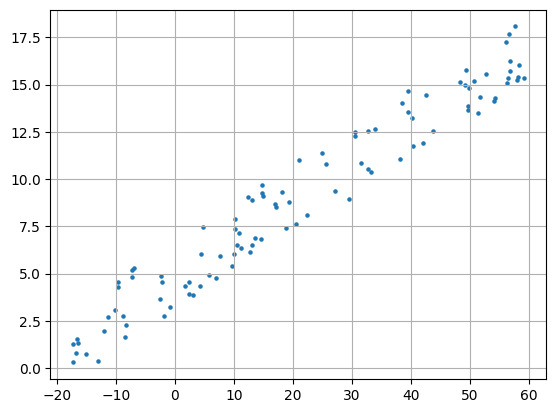

In [7]:
# Datos para ajustar
x=np.random.uniform(-20,60,100)
x.sort()
y=5+1/5*x+np.random.uniform(-2,2,100)
plt.scatter(x,y,s=5)
plt.grid()

In [8]:
sol=opt.minimize(criterio_opt,beta0,args=(x,y))
sol

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 125.9727248136756
        x: [ 4.725e+00  2.001e-01]
      nit: 3
      jac: [ 9.537e-07 -9.537e-07]
 hess_inv: [[ 8.980e-03 -1.884e-04]
            [-1.884e-04  8.918e-06]]
     nfev: 18
     njev: 6

In [9]:
# Criterio de optimización óptimo (suma de errores al cuadrado)
sol.fun

np.float64(125.9727248136756)

In [10]:
# Parámetros que generan la solución óptima
sol.x

array([4.72548806, 0.20010217])

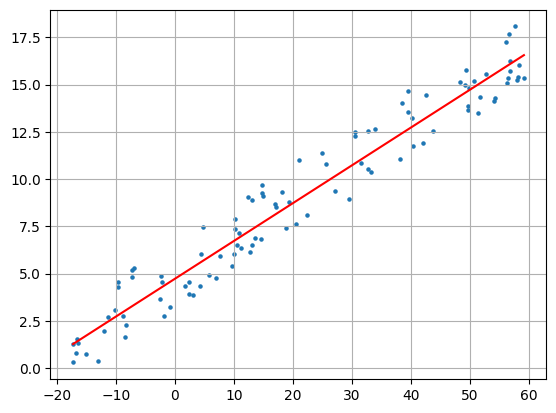

In [11]:
plt.scatter(x,y,s=5)
f=sol.x[0]+sol.x[1]*x     # Modelo de regresión lineal óptimo
plt.plot(x,f,'r')
plt.grid()

## Ajuste polinomial

Ahora, considere el siguiente conjunto de datos...

## Generación de cualquier modelo
$$
\beta_0x^0+\beta_1x^1+\beta_2x^2+\dots+\beta_nx^n.
$$
Generando el vector de potencias de $x$:
$$
\left[x^0, x^1, \dots, x^{n}\right]
$$

In [12]:
n=len(beta0)-1
print("Grado del polinomio: ",n)
X=np.array([x**i for i in range(n+1)])

Grado del polinomio:  1


El modelo es el producto punto entre el vector de potencias de $x$ y $\beta$

In [13]:
f=np.dot(beta0,X)

In [14]:
def criterio_opt(beta,x,y):
  n=len(beta)
  X=np.array([x**i for i in range(n)]) # Polinomio de grado n-1
  f=np.dot(beta,X)
  return np.sum((y-f)**2)

In [15]:
beta0=np.random.rand(3) # Ajuste a una parábola
sol2=opt.minimize(criterio_opt,beta0,args=(x,y))
sol2

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 123.70528934635045
        x: [ 4.746e+00  2.140e-01 -3.114e-04]
      nit: 8
      jac: [ 1.907e-06  1.907e-06 -1.907e-06]
 hess_inv: [[ 9.068e-03 -1.271e-04 -1.374e-06]
            [-1.271e-04  5.149e-05 -9.540e-07]
            [-1.374e-06 -9.540e-07  2.138e-08]]
     nfev: 52
     njev: 13

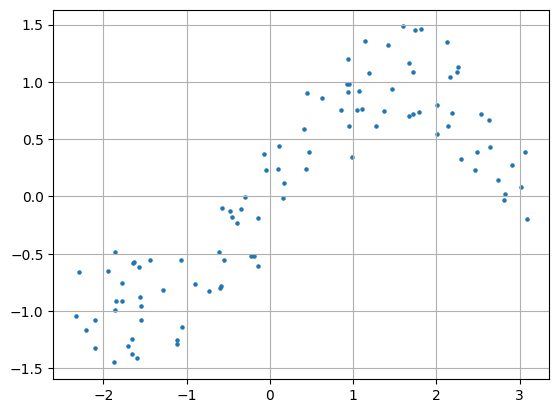

In [16]:
# Definimos una disperción de puntos con una senoidal
x=np.random.uniform(-np.pi*3/4,np.pi,100)
x.sort()
y=np.sin(x)+np.random.uniform(-0.5,0.5,100)
plt.scatter(x,y,s=5)
plt.grid()

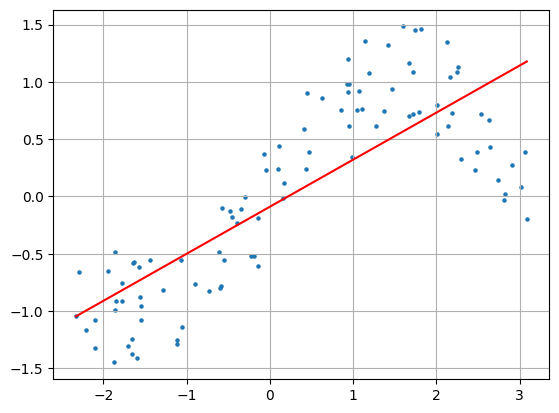

In [17]:
# Ajuste lineal
beta0=np.random.rand(2)
sol1=opt.minimize(criterio_opt,beta0,args=(x,y))

plt.scatter(x,y,s=5)
f=sol1.x[0]+sol1.x[1]*x
plt.plot(x,f,'r')
plt.grid()

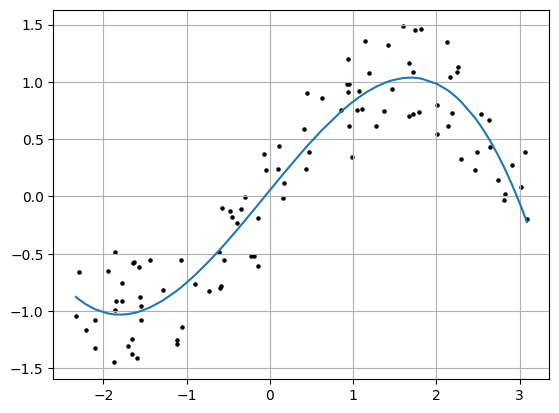

In [18]:
n=4 # Polinomio de grado 3
beta0=np.random.rand(n)
sol=opt.minimize(criterio_opt,beta0,args=(x,y))

X=np.array([x**i for i in range(n)])
f=np.dot(sol.x,X)
plt.scatter(x,y,s=5,c='k')
plt.plot(x,f,label="Grado "+str(n-1)+". err="+str(round(sol.fun,3)))
plt.grid()

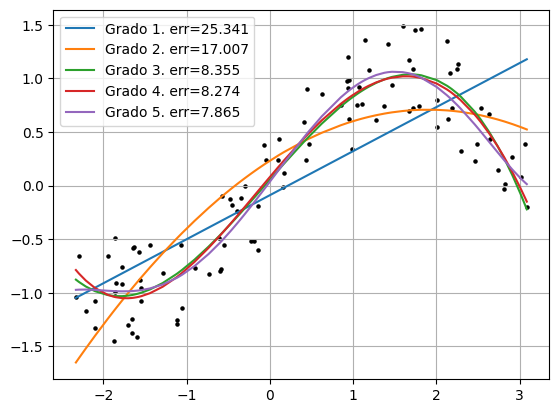

In [19]:
plt.scatter(x,y,s=5,c='k')
for n in range(2,7):  # Ajuste de polinomios de grado 1 hasta 5
  beta0=np.random.rand(n)
  sol=opt.minimize(criterio_opt,beta0,args=(x,y))

  X=np.array([x**i for i in range(n)])
  f=np.dot(sol.x,X)
  plt.plot(x,f,label="Grado "+str(n-1)+". err="+str(round(sol.fun,3)))
plt.legend()
plt.grid()

In [20]:
# Polinomio de grado 5
sol.x

array([ 0.03623204,  1.0288671 ,  0.03138737, -0.17923716, -0.01187673,
        0.01017414])

## Regularización

Vimos que la solución de mínimos cuadrados es:
$$\boldsymbol{\beta}^{ls} = \arg \min_{\boldsymbol{\beta}} \left|\left|\boldsymbol{y}-\boldsymbol{X}\boldsymbol{\beta}\right|\right|^2.$$

Sin embargo, si crecemos el orden del modelo hay overfitting y algunos coeficientes óptimos $\boldsymbol{\beta}$ crecen muchísimo. Que un coeficiente sea muy grande, significa que se le da mucha importancia a alguna característica (que quizá sea ruido... no sirve para predecir).

La regularización consiste en penalizar la magnitud de los coeficientes $\boldsymbol{\beta}$ en el problema de optimización, para que no crezcan tanto.

### Ridge

$$\boldsymbol{\beta}^{ridge} = \arg \min_{\boldsymbol{\beta}} \left|\left|\boldsymbol{y}-\boldsymbol{X}\boldsymbol{\beta}\right|\right|^2 + \lambda\left|\left|\boldsymbol{\beta}\right|\right|^2$$

In [21]:
# Conservamos el modelos de regresión pero modificamos el criterio de optimización
#
def ridge(beta,x,y,lmbd):
  n=len(beta)
  X=np.array([x**i for i in range(n)])
  f=np.dot(beta,X)                     # Mismo modelo
  return np.sum((y-f)**2)+lmbd*(beta**2).sum()

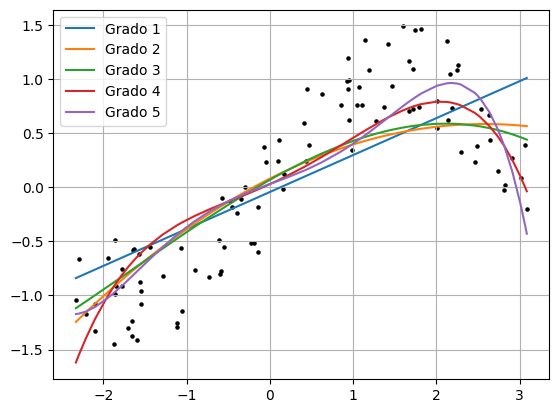

In [22]:
sol=[]
lmbd=50
plt.scatter(x,y,c='k',s=5)
for n in range(2,7):
  beta0=np.random.rand(n)
  sol.append(opt.minimize(ridge,beta0,args=(x,y,lmbd)))

  X=np.array([x**i for i in range(n)])
  f=np.dot(sol[-1].x,X)                # sol[-1]  ->  última solución almacenada
  plt.plot(x,f,label='Grado '+str(n-1))
plt.legend()
plt.grid()

In [23]:
# Polinomio de grado 5
sol[4].x # Coeficientes más equilibrados

array([ 0.02910833,  0.28597467, -0.00939438,  0.11485057, -0.00322847,
       -0.01549882])

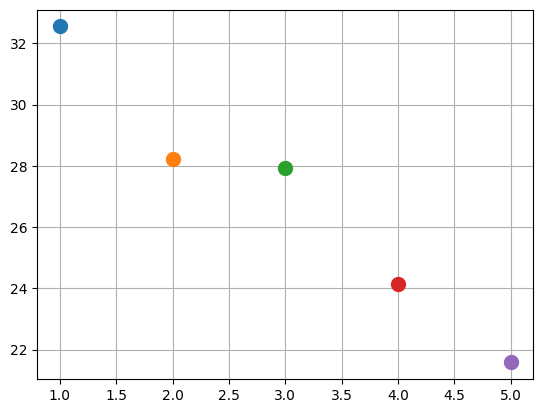

In [24]:
for n,err in enumerate(sol):
  plt.plot(n+1,err.fun,'o',ms=10)
plt.grid()

### Lasso

$$\boldsymbol{\beta}^{lasso} = \arg \min_{\boldsymbol{\beta}} \left|\left|\boldsymbol{y}-\boldsymbol{X}\boldsymbol{\beta}\right|\right|^2 + \lambda\left|\left|\boldsymbol{\beta}\right|\right|_1$$

La norma 1 no es más que la suma de los valores absolutos de las componentes $\left|\left|\boldsymbol{\beta}\right|\right|_1=\sum_{j=0}^m\left|\beta_j\right|$.

In [25]:
# Otro creiterio de optimización
#
def lasso(beta,x,y,lmbd):
  n=len(beta)
  X=np.array([x**i for i in range(n)])
  f=np.dot(beta,X)                     # Mismo modelo
  return np.sum((y-f)**2)+lmbd*(np.abs(beta)).sum()

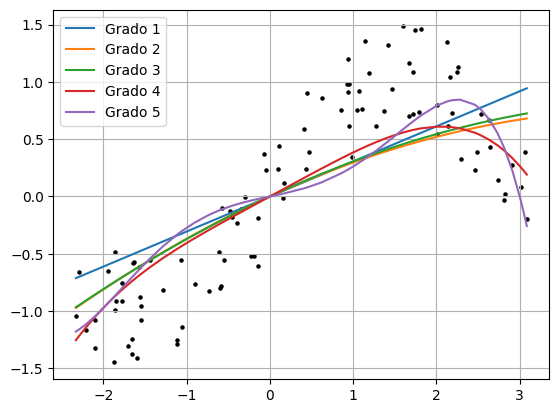

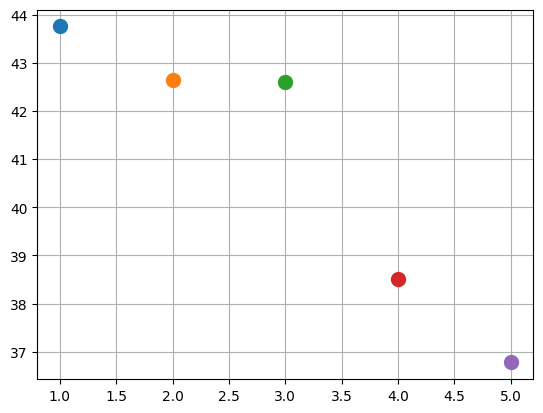

In [26]:
# Polinomios
sol=[]
lmbd=50
plt.scatter(x,y,c='k',s=5)
for n in range(2,7):
  beta0=np.random.rand(n)
  sol.append(opt.minimize(lasso,beta0,args=(x,y,lmbd)))

  X=np.array([x**i for i in range(n)])
  f=np.dot(sol[-1].x,X)                # sol[-1]  ->  última solución almacenada
  plt.plot(x,f,label='Grado '+str(n-1))
plt.legend()
plt.grid()

# Errores
plt.figure()
for n,err in enumerate(sol):
  plt.plot(n+1,err.fun,'o',ms=10)
plt.grid()

# Clasificación binaria

<img style="float: right; margin: 0px 0px 15px 15px;" src="https://static.pexels.com/photos/616020/pexels-photo-616020.jpeg" width="400px" height="200px" />

> Lo que veremos en esta clase son aspectos básicos de lo que se conoce técnicamente con muchos nombres sofisticados: aprendizaje de máquina (machine learning), clasificación con redes neuronales (neural networks), entre otros.

**Referencia**
- https://es.coursera.org/learn/neural-networks-deep-learning
___

## Formulación del problema

###  Idea básica

<img style="float: right; margin: 0px 0px 15px 15px;" src="https://upload.wikimedia.org/wikipedia/commons/d/db/Logo_ITESO_normal.jpg" width="150px" height="200px" />

Presentamos la idea básica de clasificación binaria mediante un ejemplo.

Tenemos como *entrada* una imagen digital y como *salida* una etiqueta que identifica a esta imagen como el logo del ITESO (en cuyo caso la etiqueta toma el valor de uno '1') o no (en cuyo caso la etiqueta toma el valor de cero '0').

A la salida la denotaremos $y$.

**¿Cómo guarda las imágenes un computador?** Código de colores RGB.

<font color = red>
$$R=\left[\begin{array}{cccc}255 & 124 & \dots & 45\\ 235 & 224 & \dots & 135\\ \vdots & \vdots & & \vdots\\ 23 & 12 & \dots & 242\end{array}\right]$$
</font>
<font color = green>
$$G=\left[\begin{array}{cccc}255 & 154 & \dots & 42\\ 215 & 24 & \dots & 145\\ \vdots & \vdots & & \vdots\\ 0 & 112 & \dots & 232\end{array}\right]$$
</font>
<font color = blue>
$$B=\left[\begin{array}{cccc}255 & 231 & \dots & 145\\ 144 & 234 & \dots & 35\\ \vdots & \vdots & & \vdots\\ 5 & 52 & \dots & 42\end{array}\right]$$
</font>

Cada matriz tiene tamaño correspondiente con los pixeles de la imagen. Si la imagen se de $64px\times 64px$, cada matriz será de $64\times 64$.

**¿Cómo podemos convertir entonces una imagen en una entrada?** Ponemos cada valor de cada matriz en un vector de características $\boldsymbol{x}$:

$$\boldsymbol{x}=\left[\begin{array}{ccc} \text{vec}R & \text{vec}G & \text{vec}B \end{array}\right]^T=\left[\begin{array}{ccccccccc} 255 & 124 & \dots & 255 & 154 & \dots & 255 & 231 & \dots \end{array}\right]^T$$

Entonces el problema de clasificación se puede resumir como dado un vector de entrada $\boldsymbol{x}$ (en este caso un vector con las intensidades de rojo, verde y azul por pixel de una imagen), predecir si la etiqueta correspondiente $y$ toma el valor de $1$ o $0$ (si es logo del ITESO o no).

### Notación
En adelante seguiremos la siguiente notación.

Un ejemplo de entrenamiento se representa por la pareja ordenada $(\boldsymbol{x},y)$, donde $\boldsymbol{x}\in\mathbb{R}^n$ y $y\in\left\lbrace0,1\right\rbrace$.

Tendremos $m$ ejemplos de entrenamiento, de modo que nuestro conjunto de entrenamiento será $\left\lbrace(\boldsymbol{x}^1,y^1),(\boldsymbol{x}^2,y^2),\dots,(\boldsymbol{x}^m,y^m)\right\rbrace$.

Por otra parte, para presentar de forma más compacta las entradas de entrenamiento, definimos la matriz

$$\boldsymbol{X}=\left[\begin{array}{c} {\boldsymbol{x}^1}^T \\ {\boldsymbol{x}^2}^T \\ \vdots \\ {\boldsymbol{x}^m}^T \end{array}\right]\in\mathbb{R}^{m\times n},$$

cuyas filas son los vectores de entrenamiento de entrada transpuestos, y el vector

$$\boldsymbol{Y}=\left[\begin{array}{c} y^1 \\ y^2 \\ \vdots \\ y^m \end{array}\right]\in\mathbb{R}^{m},$$

cuyas componentes son las etiquetas (salidas) de entrenamiento.

## Regresión logística

La idea entonces es, dado un vector de características $\boldsymbol{x}$ (quizá correspondiente a una imagen que queramos identificar como el logo del ITESO o no), queremos obtener una predicción $\hat{y}$ que es nuestro estimado de $y$.

Formalmente $\hat{y}=P(y=1|\boldsymbol{x})\in\left[0,1\right]$...

Los parámetros de regresión serán $\boldsymbol{\beta}=\left[\beta_0\quad \beta_1\quad \dots\quad \beta_n \right]^T\in\mathbb{R}^{n+1}.$

**Primera idea:** usar una regresor lineal

$$\hat{y}=\beta_0+\beta_1x_1+\beta_2x_2+\dots+\beta_nx_n=\left[1\quad \boldsymbol{x}^T\right]\boldsymbol{\beta}=\boldsymbol{x}_a^T\boldsymbol{\beta},$$

donde $\boldsymbol{x}_a=\left[1\quad \boldsymbol{x}^T \right]^T\in\mathbb{R}^{n+1}$.

¿Cuál es el problema? Que el producto punto $\boldsymbol{\beta}^T\boldsymbol{x}_a$ no está entre $0$ y $1$.

**Entonces,** pasamos el regresor lineal por una sigmoide (función logística)

$$\sigma(z)=\frac{1}{1+e^{-z}}$$

In [27]:
# Definimos la sigmoidal (Función de activación en redes neuronales)
def sigm(z):
  return 1/(1+np.exp(-z))

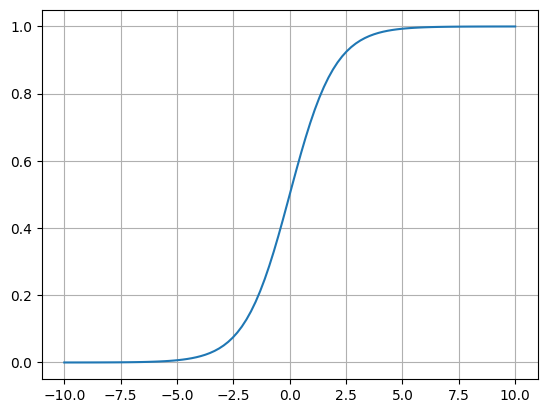

In [28]:
z=np.linspace(-10,10,100)
plt.plot(z,sigm(z))
plt.grid()

Notamos que:
- Si $z$ es grande, $\sigma(z)=1$.
- Si $-z$ es grande, $\sigma(z)=0$.
- $\sigma(0)=0.5$.

Finalmente...

**Regresor logístico:** $\hat{y}=\sigma(\boldsymbol{x}_a^T\boldsymbol{\beta})$.

Para manejar todos los datos de entrenamiento, se define la matriz

$$\boldsymbol{X}_a=\left[\boldsymbol{1}_{m\times 1}\quad \boldsymbol{X}\right]=\left[\begin{array}{cc} 1 & {\boldsymbol{x}^1}^T \\ 1 & {\boldsymbol{x}^2}^T \\ \vdots & \vdots \\ 1 & {\boldsymbol{x}^m}^T \end{array}\right]\in\mathbb{R}^{m\times (n+1)}.$$

Así,

$$\hat{\boldsymbol{Y}}=\left[\begin{array}{c} \hat{y}^1 \\ \hat{y}^2 \\ \vdots \\ \hat{y}^m \end{array}\right]=\sigma(\boldsymbol{X}_a\boldsymbol{\beta})$$

In [29]:
# Definición del modelo
def modelo(beta,X):
  m=len(X) # Tamaño de datos
  Xa=np.concatenate([np.ones((m,1)),X],axis=1)
  z=Xa.dot(beta)
  return sigm(z)

## Funcional de costo
Ya que tenemos definida la forma de nuestro modelo clasificador, debemos **entrenar** los parámetros $\boldsymbol{\beta}$ con los ejemplos de entrenamiento.

Es decir, dados  $\left\lbrace(\boldsymbol{x}^1,y^1),(\boldsymbol{x}^2,y^2),\dots,(\boldsymbol{x}^m,y^m)\right\rbrace$, queremos encontrar parámetros $\boldsymbol{\beta}$ tales que $\hat{y}^i=\sigma({\boldsymbol{x}_a^i}^T\boldsymbol{\beta})\approx y^i$ 'lo mejor posible'.

Esto lo plantearemos como un problema de optimización.

**Primera idea:** minimizar error cuadrático $\min_{\boldsymbol{\beta}} \frac{1}{m}\sum_{i=1}^m (\hat{y}^i-y^i)^2$. Problema de optimización *no convexo*.

**Alternativa:** entonces, se buscó una función de modo que el problema de optimización fuera convexo. Esta es:

$$\min_{\boldsymbol{\beta}} \frac{1}{m}\sum_{i=1}^m -\left(y^i\log(\hat{y}^i)+(1-y^i)\log(1-\hat{y}^i)\right)$$

No pretendemos explicar toda esta función. Pero sí podemos ganar algo de intuición de porqué la usamos. Fijemos un $i$ dentro del sumatorio y consideremos el término $-\left(y^i\log(\hat{y}^i)+(1-y^i)\log(1-\hat{y}^i)\right)$.

- Si $y^i=1$, entonces lo que queremos minimzar es $-\log(\hat{y}^i)$. Es decir, queremos que $\hat{y}^i=\sigma({\boldsymbol{x}_a^i}^T\boldsymbol{\beta})$ sea lo más grande posible, osea $1=y^i$.
- Si $y^i=0$, entonces lo que queremos minimzar es $-\log(1-\hat{y}^i)$. Es decir, queremos que $\hat{y}^i=\sigma({\boldsymbol{x}_a^i}^T\boldsymbol{\beta})$ sea lo más pequeño posible, osea $0=y^i$.

En cualquier caso, esta función objetivo cumple con lo requerido.

In [30]:
# Criterio de optimización para regresión logística
def criterio_opt(beta,X,y):
  f=modelo(beta,X)
  return (-y*np.log(f)-(1-y)*np.log(1-f)).mean()

In [31]:
X=np.random.uniform(0,2,(100,2))
y=(2*X[:,0]**2>X[:,1]).astype('int')
# plt.scatter(X[:,0],X[:,1],c=y)

In [32]:
beta0=np.array([0,0,0])
sol=opt.minimize(criterio_opt,beta0,args=(X,y))
sol

C:\Users\orlan\AppData\Local\Temp\ipykernel_9252\95212068.py:4: RuntimeWarning: divide by zero encountered in log
  return (-y*np.log(f)-(1-y)*np.log(1-f)).mean()
C:\Users\orlan\AppData\Local\Temp\ipykernel_9252\95212068.py:4: RuntimeWarning: invalid value encountered in multiply
  return (-y*np.log(f)-(1-y)*np.log(1-f)).mean()
C:\Users\orlan\AppData\Local\Temp\ipykernel_9252\2296533560.py:3: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-z))
C:\Users\orlan\AppData\Local\Temp\ipykernel_9252\95212068.py:4: RuntimeWarning: divide by zero encountered in log
  return (-y*np.log(f)-(1-y)*np.log(1-f)).mean()
C:\Users\orlan\AppData\Local\Temp\ipykernel_9252\95212068.py:4: RuntimeWarning: invalid value encountered in multiply
  return (-y*np.log(f)-(1-y)*np.log(1-f)).mean()
C:\Users\orlan\AppData\Local\Temp\ipykernel_9252\2296533560.py:3: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-z))
C:\Users\orlan\AppData\Local\Temp\ipykernel_9252\2296533560.py:3: Ru

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: nan
        x: [-4.566e+02  2.562e+03 -1.101e+03]
      nit: 14
      jac: [       nan        nan        nan]
 hess_inv: [[ 1.099e+02 -6.138e+02  2.858e+02]
            [-6.138e+02  3.459e+03 -1.611e+03]
            [ 2.858e+02 -1.611e+03  7.547e+02]]
     nfev: 500
     njev: 125

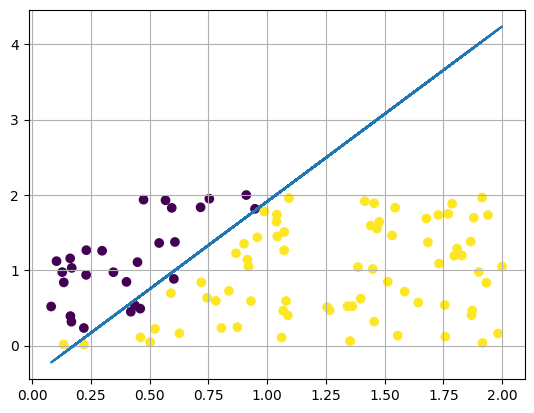

In [33]:
plt.scatter(X[:,0],X[:,1],c=y)
separacion=(-sol.x[0]-sol.x[1]*X[:,0])/sol.x[2]  # (-beta_0-beta_1*x1)/beta_2
plt.plot(X[:,0],separacion)
plt.grid()

**Ejemplo**

El archivo `ex2data1.txt` contiene datos de puntajes de dos exámenes de admisión (1 y 2), y etiquetas de si el respectivo estudiante fue admitido o no a la universidad.

In [34]:
import pandas as pd

In [35]:
df=pd.read_csv('ex2data1.txt',header=None)
X=df[[0,1]].values
y=df[2]

[-25.16120878   0.20623073   0.20147056]


C:\Users\orlan\AppData\Local\Temp\ipykernel_9252\95212068.py:4: RuntimeWarning: divide by zero encountered in log
  return (-y*np.log(f)-(1-y)*np.log(1-f)).mean()
C:\Users\orlan\AppData\Local\Temp\ipykernel_9252\95212068.py:4: RuntimeWarning: divide by zero encountered in log
  return (-y*np.log(f)-(1-y)*np.log(1-f)).mean()
c:\Users\orlan\OneDrive - ITESO\ITESO\Semestre 7\Simulación Matemática\.venv\Lib\site-packages\scipy\optimize\_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
C:\Users\orlan\AppData\Local\Temp\ipykernel_9252\95212068.py:4: RuntimeWarning: divide by zero encountered in log
  return (-y*np.log(f)-(1-y)*np.log(1-f)).mean()
c:\Users\orlan\OneDrive - ITESO\ITESO\Semestre 7\Simulación Matemática\.venv\Lib\site-packages\scipy\optimize\_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
C:\Users\orlan\AppData\Local\Temp\ipykernel_9252\95212068.py:4: RuntimeWarning: divide by zero encountered in

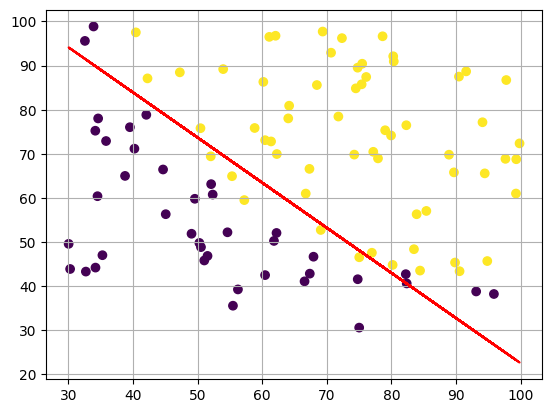

In [37]:
beta0=np.zeros(3)
sol1=opt.minimize(criterio_opt,beta0,args=(X,y))
plt.scatter(X[:,0],X[:,1],c=y)
print(sol1.x)
separacion=(-sol1.x[0]-sol1.x[1]*X[:,0])/sol1.x[2]
plt.plot(X[:,0],separacion,'r')
plt.grid()

Variables de entrada:
$$
x_1 = \mathrm{Examen1}, \qquad
x_2 = \mathrm{Examen2}
$$

Variable de salida:
$$
y = \mathrm{Admitido}
$$

Modelo
$$
\hat{y} = \sigma(\beta_0 + \beta_1 x_1 + \beta_2 x_2)
$$

Construir un clasificador binario por regresión lineal logística.

$$\min_{\boldsymbol{\beta}} \frac{1}{m}\sum_{i=1}^m -\left(y^i\log(\hat{y}^i)+(1-y^i)\log(1-\hat{y}^i)\right)$$